In [2]:
import numpy as np
import astero_solver as ast
from astero_solver import relations

In [ ]:
solver = ast.Solver(nlive=500, seed=0)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
numax             3101       201.4        2902        3098        3301
dnu              138.6       5.498       133.1       138.6       144.2


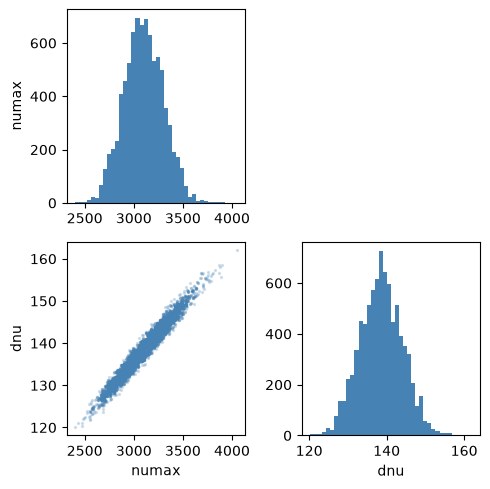

In [5]:

# Case 1: full info given -> numax (solar metallicity)
given = {"M": (1.0, 0.05), "R": (1.0, 0.02), "Teff": (5777, 50), "FeH": (0.0, 0.05)}
out = solver.solve(given, want=["numax", "dnu"])
ast.summarize(out)
fig = ast.plot_posterior(out)
fig.savefig("posterior_1.png", dpi=120)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
R               0.9998    0.004501      0.9955      0.9998       1.004
dnu              138.4      0.3298         138       138.4       138.7
rho              1.001    0.004842      0.9957       1.001       1.005


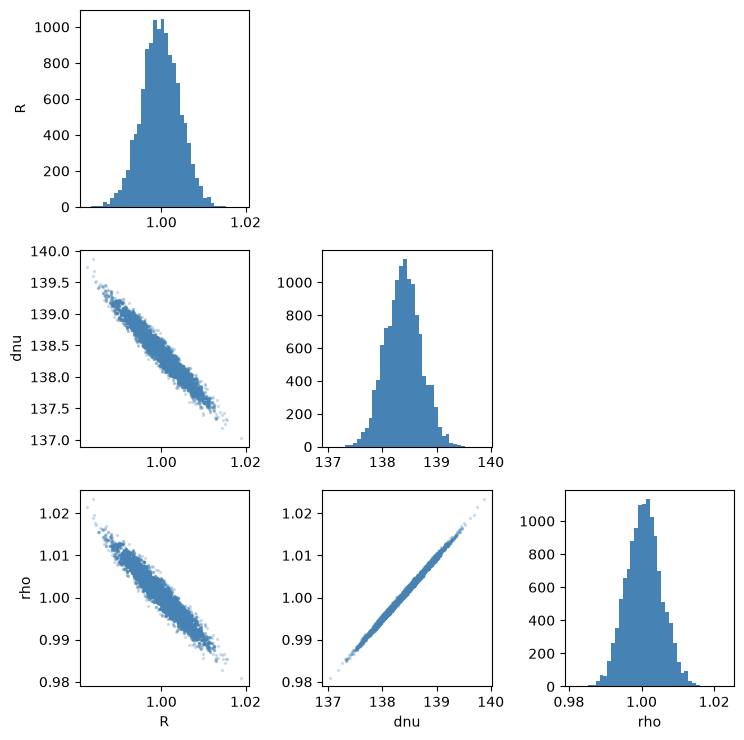

In [10]:
# Case 2: radius left out -> marginalize over R prior
given = {"M": (1.0, 0.01),  "R": (1.0, 0.01), "Teff": (5777, 10), "FeH": (0.0, 0.01), "numax": (3090, 3)}
out = solver.solve(given, want=["R", "dnu", "rho"])
ast.summarize(out)
fig = ast.plot_posterior(out)
fig.savefig("posterior_2.png", dpi=120)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M                1.103     0.04834       1.055       1.102       1.152
R                 1.05     0.01929        1.03       1.049       1.069
rho             0.9533     0.01456       0.939      0.9536      0.9681


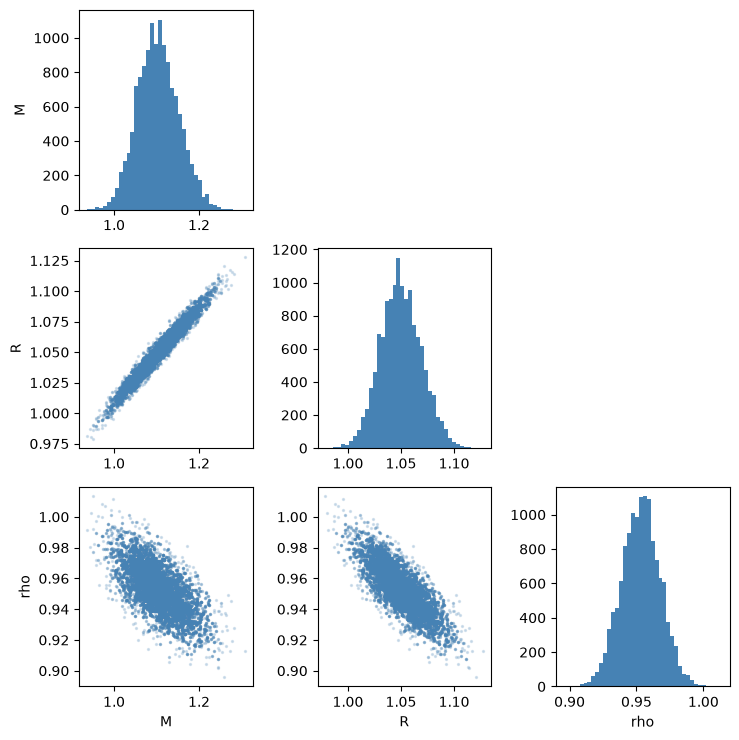

In [7]:
# Case 3: seismic + Gaia constraints -> M and R, no mass/radius given directly
given = {
    "Teff": (5777, 50),
    "FeH": (0.0, 0.05),
    "numax": (3090, 30),
    "dnu": (135.1, 1.0),
    "plx": (10.0, 0.1),   # mas -> ~100 pc
    "G_mag": (9.90, 0.02),
}
out = solver.solve(given, want=["M", "R", "rho"])
ast.summarize(out)

# quick sanity-check plot of the joint posterior
fig = ast.plot_posterior(out)
fig.savefig("posterior_3.png", dpi=120)

In [8]:





# Case 4: same thing, but via the top-level solve() shortcut, no Solver needed
out = ast.solve(given, want=["M", "R"])
ast.summarize(out)

# metallicity correction sanity check
print()
print("f_numax([Fe/H]=0.0):", relations.f_numax(0.0))
print("f_numax([Fe/H]=-2.0):", relations.f_numax(-2.0))
print("dnu_ref(Teff=4800, [Fe/H]=0.0):", relations.dnu_ref(4800, 0.0))
print("dnu_ref(Teff=4800, [Fe/H]=-2.0):", relations.dnu_ref(4800, -2.0))


param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M                1.104     0.04762       1.056       1.101       1.152
R                 1.05     0.01895       1.031        1.05       1.069

f_numax([Fe/H]=0.0): 1.0
f_numax([Fe/H]=-2.0): 0.9816018911061287
dnu_ref(Teff=4800, [Fe/H]=0.0): 134.10044887259966
dnu_ref(Teff=4800, [Fe/H]=-2.0): 132.1642674226219
